# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-17: PhysDrive Phase-3 Preprocessing

### What this notebook does
Maps the PhysDrive release (in-vehicle driver recordings) into the unified Phase-3 schema: one consolidated HDF5 with one group per segment. Frames are decoded from each segment's RGB video and face-cropped to 72x72; the BVP label is the fingertip pulse waveform shipped resampled to the 30 Hz frame grid, END-aligned to the label length. ECG, HR and SpO2 are stored as auxiliary references with their validity masks.

### Role in Phase 3 - training (HR/BVP), respiration masked
PhysDrive joins the training corpus as a clean HR/BVP source on the hardest realistic domain (in-vehicle motion and dynamic natural light), which the five-architecture screen indicated is what MCD's error ceiling needs. Per the exploration (NB_P3_16), the shipped RESP channel is NOT a usable respiration reference - cross-sensor agreement at chance, energy plateau near half the heart rate - so the respiration head stays masked; RESP is stored raw for provenance only and is never consumed as an RR target.

### Pipeline
`{subject}/{segment}/` -> for each segment (road x action state):
  decode `Video/RGB.mp4` -> MediaPipe face box (stable, from sampled frames) -> crop + resize to 72
  `Label/BVP.mat` (30 Hz, frame-synced) -> END-align to the video (drop leading excess frames) = frame-synced bvp
  `Label/{ECG,HR,SPO2}.mat` stored as auxiliary references (HR/SpO2 sentinel-masked); `RESP.mat` stored raw + masked
  metadata (vehicle, gender, lighting, road, action) decoded from the folder names
  -> write one group per segment into the consolidated PhysDrive Phase-3 HDF5.

### Unified Phase-3 schema (v1) — PhysDrive specifics
Same grouped 72x72 layout as the other Phase-3 datasets. Each segment group (named `{subject}_{segment}`, e.g. `AFH1_AS`) holds:

| name | source | present | notes |
|------|--------|---------|-------|
| frames | face-cropped RGB video | yes | [T, 72, 72, 3] uint8 |
| bvp | fingertip BVP (30 Hz, END-aligned) | yes | frame-synced pulse label |
| ecg | PhysioLAB ECG (30 Hz) | optional | auxiliary; coarse at 30 Hz |
| hr | device HR (30 Hz) | optional | sentinel 255 -> NaN |
| spo2 | device SpO2 (30 Hz) | optional | sentinel 127 -> NaN |
| resp_raw | shipped RESP (30 Hz) | optional | NOT respiration (see NB_P3_16); masked, never an RR target |

Key attributes: `role='train'`, `subject_id` (4-char driver code), `vehicle`/`gender`/`lighting` (from the folder name), `segment`/`road`/`action` (from the segment name), `cardiac_sqi` (SQI-gated usability), availability flags (`has_bvp`/`has_ecg`/`has_hr`/`has_spo2`=True, `has_resp`=False), `hr_valid_frac`/`spo2_valid_frac`, and `excess_frames_dropped`. `usable` gates on cardiac SQI, duration, exposure and face detection.

## 1. Imports & Config

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import h5py
import matplotlib.pyplot as plt
from scipy.io import loadmat
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

PHYSDRIVE_DIR = Path(r'F:\PhysDrive(Pub)') # dataset root (subject folders live under here)
MP_MODEL = Path(r'D:\code\QualityPhys - CRVSE Project\app\live_hr_demo\models\mediapipe\face_landmarker.task')
DATASET_NAME = 'physdrive'
OUT_DIR = Path(r'F:\rppg\phase3') # large frame output -> keep off the small project drive
OUT_H5 = OUT_DIR / f'{DATASET_NAME}_phase3.h5'
LOG_PATH = OUT_DIR / f'processing_log_{DATASET_NAME}_phase3.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 72 # committed corpus-wide frame size
CROP_PADDING = 0.6 # expand the face box (forehead + cheeks)
N_DETECT_FRAMES = 15 # frames sampled to compute a stable face box
LABEL_FS = 30.0 # all labels ship resampled to the 30 Hz frame grid
FPS_FALLBACK = 30.0
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.7, 3.5
HR_SENTINEL, SPO2_SENTINEL = 255.0, 127.0

# Quality: training set -> gate on cardiac SQI plus genuine corruption.
SQI_FLOOR = 0.05
MIN_DURATION_S = 30.0
FRAME_DARK, FRAME_BRIGHT = 5.0, 250.0

# Segment suffix mapping (per NB_P3_16 - confirm the S/T resolution against that notebook).
ACTION = {'S': 'stationary', 'T': 'talking'}

SCHEMA_VERSION = 'p3_v1'
ROLE = 'train'
OVERWRITE = False
MAX_RECORDS = None # set to an int (e.g. 4) for a trial run

print('PhysDrive dir exists:', PHYSDRIVE_DIR.exists())
print('MediaPipe model exists:', MP_MODEL.exists())
print('Output store:', OUT_H5)

PhysDrive dir exists: True
MediaPipe model exists: True
Output store: F:\rppg\phase3\physdrive_phase3.h5


## 2. Helper functions (labels, face crop, alignment)

In [3]:
def cardiac_metrics(sig, fps, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ):
    '''Returns the cardiac-band spectral HR (bpm) and a 3-bin peak-power fraction SQI from a pulse waveform.'''
    x = np.asarray(sig, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    return float(freqs[band][pk] * 60.0), float(bp[max(0, pk - 1):pk + 2].sum() / bp.sum())


def video_fps(path, fallback=FPS_FALLBACK):
    '''Returns the video frame rate from OpenCV, or a fallback if unavailable.'''
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps) if fps and fps > 1.0 else fallback


def load_label(mat_path):
    '''Loads a PhysDrive label .mat (variable name = file stem, shape (1,N)) as a 1-D float32 array, or None.'''
    if not mat_path.exists():
        return None
    m = loadmat(mat_path)
    keys = [k for k in m if not k.startswith('__')]
    if not keys:
        return None
    return np.asarray(m[keys[0]]).squeeze().astype(np.float32)


def end_align(frames, label_len):
    '''END-aligns the decoded frames to the label length by dropping the leading excess frames (per NB_P3_16).'''
    n = len(frames)
    excess = n - label_len
    if excess > 0:
        frames = frames[excess:]
    T = min(len(frames), label_len)
    return frames[:T], T, max(excess, 0)


def make_landmarker():
    '''Creates a MediaPipe FaceLandmarker in single-image mode.'''
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MP_MODEL)),
        running_mode=mp_vision.RunningMode.IMAGE, num_faces=1)
    return mp_vision.FaceLandmarker.create_from_options(opts)


def stable_face_box(frames_rgb, landmarker, padding=CROP_PADDING):
    '''Returns a square relative face box (rx0, ry0, rx1, ry1) as the median detection over sample frames.'''
    boxes = []
    for frame in frames_rgb:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame))
        res = landmarker.detect(mp_img)
        if not res.face_landmarks:
            continue
        lm = res.face_landmarks[0]
        xs = np.array([p.x for p in lm]); ys = np.array([p.y for p in lm])
        boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
    if not boxes:
        return None
    x0, y0, x1, y1 = np.median(np.array(boxes), axis=0)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    half = max(x1 - x0, y1 - y0) * (1.0 + padding) / 2.0
    return (cx - half, cy - half, cx + half, cy + half)


def crop_resize(frame_rgb, box, size):
    '''Crops a frame to a relative square box (clamped to the frame) and resizes to size x size.'''
    h, w = frame_rgb.shape[:2]
    x0 = max(0, int(box[0] * w)); y0 = max(0, int(box[1] * h))
    x1 = min(w, int(box[2] * w)); y1 = min(h, int(box[3] * h))
    if x1 <= x0 or y1 <= y0:
        return None
    return cv2.resize(frame_rgb[y0:y1, x0:x1], (size, size), interpolation=cv2.INTER_AREA)


def extract_face_frames(video_path, landmarker, size=TARGET_SIZE, n_detect=N_DETECT_FRAMES):
    '''Decodes a video, computes a stable face box from sampled frames, and returns cropped size x size frames.'''
    cap = cv2.VideoCapture(str(video_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 100000
    sample_at = sorted(set(np.linspace(0, max(n_total - 1, 0), n_detect).astype(int)))
    samples = []
    for i in sample_at:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, bgr = cap.read()
        if ok:
            samples.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    box = stable_face_box(samples, landmarker) if samples else None
    if box is None:
        cap.release(); return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    out = []
    while True:
        ok, bgr = cap.read()
        if not ok:
            break
        c = crop_resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), box, size)
        if c is not None:
            out.append(c)
    cap.release()
    return np.asarray(out, dtype=np.uint8) if out else None

def windowed_cardiac(sig, fps, win_s=10.0, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ):
    '''Median per-window spectral HR and SQI over ~win_s windows - HR-drift-robust, at the clip scale the model sees.'''
    x = np.asarray(sig, float)
    w = int(win_s * fps)
    if len(x) < w:
        return cardiac_metrics(x, fps, low, high)
    hrs, sqis = [], []
    for s in range(0, len(x) - w + 1, w):
        h, q = cardiac_metrics(x[s:s + w], fps, low, high)
        if np.isfinite(h):
            hrs.append(h)
        sqis.append(q)
    return (float(np.median(hrs)) if hrs else np.nan), (float(np.median(sqis)) if sqis else 0.0)

## 3. Segment discovery
Walks the release for `RGB.mp4` files (skipping AppleDouble `__MACOSX` junk) and derives, for each, the segment folder, the parent subject folder, and the sibling `Label/` directory. The subject name encodes vehicle, gender and lighting; the segment name encodes road condition and action state.

In [4]:
def discover_segments(root):
    '''Returns a list of dicts (rgb, label_dir, subject, segment) for every RGB segment under root.'''
    jobs = []
    for rgb in sorted(root.rglob('RGB.mp4')):
        if '__MACOSX' in rgb.parts or rgb.name.startswith('._'):
            continue
        seg_dir = rgb.parent.parent # {subject}/{segment}/Video/RGB.mp4 -> {subject}/{segment}
        subj_dir = seg_dir.parent
        jobs.append(dict(rgb=rgb, label_dir=seg_dir / 'Label',
                         subject=subj_dir.name, segment=seg_dir.name))
    return jobs

jobs = discover_segments(PHYSDRIVE_DIR)
print('segments found:', len(jobs))
if jobs:
    subs = sorted({j['subject'] for j in jobs})
    print('subjects:', len(subs), '| example:', subs[:6])
    print('segment names seen:', sorted({j['segment'] for j in jobs}))
    print('example job:', {k: (str(v) if isinstance(v, Path) else v) for k, v in jobs[0].items()})

segments found: 283
subjects: 48 | example: ['AFH1', 'AFH2', 'AFW1', 'AFW2', 'AFY1', 'AFY2']
segment names seen: ['AS', 'AT', 'BS', 'BT', 'CS', 'CT']
example job: {'rgb': 'F:\\PhysDrive(Pub)\\PhysDrive(Publication)\\AFH1\\AT\\Video\\RGB.mp4', 'label_dir': 'F:\\PhysDrive(Pub)\\PhysDrive(Publication)\\AFH1\\AT\\Label', 'subject': 'AFH1', 'segment': 'AT'}


## 4. Single-segment walkthrough
Processes one segment end to end (RGB decode, face-crop, END-alignment to the 30 Hz labels, sentinel masking) and prints the record numerically. Confirms the frame tensor, the BVP alignment and the metadata attributes before the full batch. No face imagery is rendered.

In [5]:
LANDMARKER = make_landmarker()

def build_record(job):
    '''Builds one unified-schema record from a PhysDrive segment job.'''
    subject, segment = job['subject'], job['segment']
    frames = extract_face_frames(job['rgb'], LANDMARKER)
    if frames is None or len(frames) == 0:
        raise RuntimeError('no frames or face not detected')
    bvp_raw = load_label(job['label_dir'] / 'BVP.mat')
    if bvp_raw is None or bvp_raw.size < 16:
        raise RuntimeError('missing or empty BVP label')
    label_n = len(bvp_raw)
    frames, T, excess = end_align(frames, label_n)
    if T < 16:
        raise RuntimeError('too few aligned frames')
    bvp = bvp_raw[:T].astype(np.float32)
    fps = video_fps(job['rgb'])
    # SQI/HR from the filtered pulse (BVP_Filt isolates the fundamental); raw BVP stays the label.
    bvp_filt = load_label(job['label_dir'] / 'BVP_Filt.mat')
    has_filt = bvp_filt is not None and len(bvp_filt) >= T
    bvp_hr, sqi = windowed_cardiac(bvp_filt[:T] if has_filt else bvp, LABEL_FS)
    

    def aux(name):
        a = load_label(job['label_dir'] / name)
        return a[:T].astype(np.float32) if a is not None and len(a) >= T else None
    ecg = aux('ECG.mat'); hr = aux('HR.mat'); spo2 = aux('SPO2.mat'); resp = aux('RESP.mat')
    if hr is not None:
        hr = np.where(hr == HR_SENTINEL, np.nan, hr).astype(np.float32)
    if spo2 is not None:
        spo2 = np.where(spo2 == SPO2_SENTINEL, np.nan, spo2).astype(np.float32)

    duration_s = T / LABEL_FS
    brightness = float(frames[T // 2].mean())
    attrs = dict(
        schema_version=SCHEMA_VERSION, dataset='PhysDrive', role=ROLE, source_file=str(job['rgb'].name),
        subject_id=subject, subject=subject, segment=segment,
        vehicle=subject[0], gender=subject[1], lighting=subject[2],
        road=segment[0], action=ACTION.get(segment[1:], segment[1:]),
        fps=float(fps), label_fs=LABEL_FS, n_frames=int(T), duration_s=float(duration_s),
        frame_size=int(TARGET_SIZE), excess_frames_dropped=int(excess),
        has_frames=True, has_bvp=True, has_ecg=bool(ecg is not None), has_hr=bool(hr is not None),
        has_spo2=bool(spo2 is not None), has_resp=False,
        cardiac_sqi=float(sqi), bvp_spectral_hr=float(bvp_hr) if np.isfinite(bvp_hr) else float('nan'),
        hr_valid_frac=float(np.mean(np.isfinite(hr))) if hr is not None else 0.0,
        spo2_valid_frac=float(np.mean(np.isfinite(spo2))) if spo2 is not None else 0.0,
        frame_ok=bool(FRAME_DARK <= brightness <= FRAME_BRIGHT),
        usable=bool(sqi >= SQI_FLOOR and duration_s >= MIN_DURATION_S and FRAME_DARK <= brightness <= FRAME_BRIGHT),
        resp_note='RESP is not usable respiration (chance-level, ~half-HR plateau; see NB_P3_16) - stored raw, masked, never an RR target',
        bvp_units_note='fingertip BVP shipped at 30 Hz, END-aligned to frames (leading excess dropped)',
        sqi_source=('BVP_Filt' if has_filt else 'BVP'))
    arrays = dict(frames=frames, bvp=bvp)
    if ecg is not None:
        arrays['ecg'] = ecg
    if hr is not None:
        arrays['hr'] = hr
    if spo2 is not None:
        arrays['spo2'] = spo2
    if resp is not None:
        arrays['resp_raw'] = resp
    return f'{subject}_{segment}', arrays, attrs


rec_id, arrays, attrs = build_record(jobs[0])
print('record:', rec_id)
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in attrs.items()}, indent=2, default=str))
print('frames', arrays['frames'].shape, '| bvp', arrays['bvp'].shape,
      '| aux', [k for k in arrays if k not in ('frames', 'bvp')])

record: AFH1_AT
{
  "schema_version": "p3_v1",
  "dataset": "PhysDrive",
  "role": "train",
  "source_file": "RGB.mp4",
  "subject_id": "AFH1",
  "subject": "AFH1",
  "segment": "AT",
  "vehicle": "A",
  "gender": "F",
  "lighting": "H",
  "road": "A",
  "action": "talking",
  "fps": 30.0,
  "label_fs": 30.0,
  "n_frames": 9074,
  "duration_s": 302.467,
  "frame_size": 72,
  "excess_frames_dropped": 5,
  "has_frames": true,
  "has_bvp": true,
  "has_ecg": true,
  "has_hr": true,
  "has_spo2": true,
  "has_resp": false,
  "cardiac_sqi": 0.733,
  "bvp_spectral_hr": 66.0,
  "hr_valid_frac": 1.0,
  "spo2_valid_frac": 1.0,
  "frame_ok": true,
  "usable": true,
  "resp_note": "RESP is not usable respiration (chance-level, ~half-HR plateau; see NB_P3_16) - stored raw, masked, never an RR target",
  "bvp_units_note": "fingertip BVP shipped at 30 Hz, END-aligned to frames (leading excess dropped)",
  "sqi_source": "BVP_Filt"
}
frames (9074, 72, 72, 3) | bvp (9074,) | aux ['ecg', 'hr', 'spo2', '

## 5. Write function and batch processing
Writes each segment as a group in one consolidated PhysDrive HDF5 on the data drive. Append mode with skip-existing makes it resumable, so a re-run folds in the rest without redoing finished segments. Set `OVERWRITE=True` to rebuild, `MAX_RECORDS` for a trial. Decoding ~283 in-vehicle segments is heavy — expect the full run to take a while.

In [6]:
def write_group(store, name, arrays, attrs):
    '''Writes one recording as a group with datasets for the present signals and all attributes.'''
    g = store.create_group(name)
    for key, value in arrays.items():
        if key == 'frames':
            g.create_dataset('frames', data=value, compression='gzip', compression_opts=1)
        else:
            g.create_dataset(key, data=value)
    for key, value in attrs.items():
        g.attrs[key] = value


def process_all(jobs, out_h5, limit=None, overwrite=False):
    '''Processes segment jobs into one consolidated per-dataset HDF5 (one group each).'''
    if limit:
        jobs = jobs[:limit]
    rows = []
    with h5py.File(out_h5, 'a') as store:
        for i, job in enumerate(jobs, 1):
            name = f"{job['subject']}_{job['segment']}"
            if name in store and not overwrite:
                a = dict(store[name].attrs); a['status'] = 'skipped'; a['error'] = ''
            else:
                try:
                    _, arrays, attrs = build_record(job)
                    if name in store:
                        del store[name]
                    write_group(store, name, arrays, attrs)
                    a = dict(attrs); a['status'] = 'ok'; a['error'] = ''
                except Exception as exc:
                    a = dict(source_file=name, subject=job['subject'], segment=job['segment'],
                             cardiac_sqi=np.nan, usable=False, status='error', error=str(exc))
            cols = ('source_file', 'subject', 'segment', 'vehicle', 'gender', 'lighting', 'road', 'action',
                    'n_frames', 'fps', 'duration_s', 'cardiac_sqi', 'bvp_spectral_hr', 'excess_frames_dropped',
                    'hr_valid_frac', 'spo2_valid_frac', 'usable', 'status', 'error')
            rows.append({c: a.get(c) for c in cols})
            print('  ', i, '/', len(jobs), name, '->', a.get('status'))
    return pd.DataFrame(rows)


log = process_all(jobs, OUT_H5, limit=MAX_RECORDS, overwrite=OVERWRITE)
log.to_csv(LOG_PATH, index=False)
print('Store:', OUT_H5)
print('Records ok:', int((log.status == 'ok').sum()), '| skipped:', int((log.status == 'skipped').sum()),
      '| errors:', int((log.status == 'error').sum()))
print('Usable:', int(log['usable'].sum()), '/', len(log))
print('Log ->', LOG_PATH)

   1 / 283 AFH1_AT -> ok
   2 / 283 AFH1_BS -> ok
   3 / 283 AFH1_BT -> ok
   4 / 283 AFH1_CS -> ok
   5 / 283 AFH1_CT -> ok
   6 / 283 AFH2_AS -> ok
   7 / 283 AFH2_AT -> ok
   8 / 283 AFH2_BS -> ok
   9 / 283 AFH2_BT -> ok
   10 / 283 AFH2_CS -> ok
   11 / 283 AFH2_CT -> ok
   12 / 283 AFW1_AS -> ok
   13 / 283 AFW1_AT -> ok
   14 / 283 AFW1_BS -> ok
   15 / 283 AFW1_BT -> ok
   16 / 283 AFW1_CS -> ok
   17 / 283 AFW1_CT -> ok
   18 / 283 AFW2_AS -> ok
   19 / 283 AFW2_AT -> ok
   20 / 283 AFW2_BS -> ok
   21 / 283 AFW2_BT -> ok
   22 / 283 AFW2_CS -> ok
   23 / 283 AFW2_CT -> ok
   24 / 283 AFY1_AS -> ok
   25 / 283 AFY1_AT -> ok
   26 / 283 AFY1_BS -> ok
   27 / 283 AFY1_BT -> ok
   28 / 283 AFY1_CS -> ok
   29 / 283 AFY1_CT -> ok
   30 / 283 AFY2_AS -> ok
   31 / 283 AFY2_AT -> ok
   32 / 283 AFY2_BS -> ok
   33 / 283 AFY2_BT -> ok
   34 / 283 AFY2_CS -> ok
   35 / 283 AFY2_CT -> ok
   36 / 283 AFZ2_AS -> ok
   37 / 283 AFZ2_AT -> ok
   38 / 283 AFZ2_BS -> ok
   39 / 283 AFZ2_BT -

## 6. Output validation
Re-opens the consolidated store, confirms the schema, verifies the frame tensor numerically (no face rendering), plots one BVP, and summarises cardiac SQI and coverage by action state and lighting.

Groups in physdrive_phase3.h5 : 283
Example group: AFH1_AT
  datasets: ['bvp', 'ecg', 'frames', 'hr', 'resp_raw', 'spo2']
  attrs: {'action': 'talking', 'bvp_spectral_hr': np.float64(66.0), 'bvp_units_note': 'fingertip BVP shipped at 30 Hz, END-aligned to frames (leading excess dropped)', 'cardiac_sqi': np.float64(0.7329754826283703), 'dataset': 'PhysDrive', 'duration_s': np.float64(302.46666666666664), 'excess_frames_dropped': np.int64(5), 'fps': np.float64(30.0), 'frame_ok': np.True_, 'frame_size': np.int64(72), 'gender': 'F', 'has_bvp': np.True_, 'has_ecg': np.True_, 'has_frames': np.True_, 'has_hr': np.True_, 'has_resp': np.False_, 'has_spo2': np.True_, 'hr_valid_frac': np.float64(1.0), 'label_fs': np.float64(30.0), 'lighting': 'H'}
  frames: (9074, 72, 72, 3) uint8 range 26 - 236


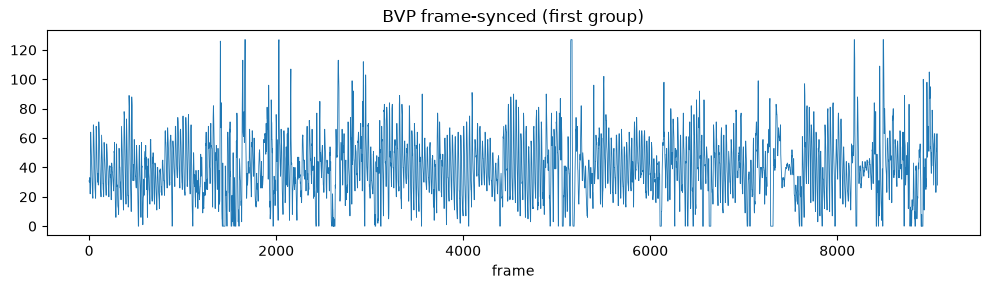

Records ok: 283 | errors: 0
Usable: 266 / 283

Cardiac SQI by action state:
             mean  median  min    max  count
action                                      
stationary  0.663   0.713  0.0  0.945    141
talking     0.637   0.686  0.0  0.819    142

Usable by lighting:
          sum  count
lighting            
H          68     68
W          66     72
Y          62     72
Z          70     71

Excess frames dropped (END-alignment): {'count': 283.0, 'mean': 3.0, 'std': 2.6, 'min': 0.0, '25%': 0.0, '50%': 3.0, '75%': 5.0, 'max': 11.0}


In [7]:
if OUT_H5.exists():
    with h5py.File(OUT_H5, 'r') as store:
        groups = sorted(store.keys())
        print('Groups in', OUT_H5.name, ':', len(groups))
        g0 = store[groups[0]]
        print('Example group:', groups[0])
        print('  datasets:', list(g0.keys()))
        print('  attrs:', {k: g0.attrs[k] for k in list(g0.attrs)[:20]})
        fr = g0['frames']
        print('  frames:', fr.shape, fr.dtype, 'range', int(fr[0].min()), '-', int(fr[0].max()))
        bvp0 = g0['bvp'][:]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(len(bvp0)), bvp0, lw=0.6)
    ax.set_title('BVP frame-synced (first group)'); ax.set_xlabel('frame')
    plt.tight_layout(); plt.show()

if len(log):
    ok = log[log.status == 'ok']
    print('Records ok:', int((log.status == 'ok').sum()), '| errors:', int((log.status == 'error').sum()))
    print('Usable:', int(log['usable'].sum()), '/', len(log))
    if len(ok):
        print('\nCardiac SQI by action state:')
        print(ok.groupby('action')['cardiac_sqi'].agg(['mean', 'median', 'min', 'max', 'count']).round(3))
        print('\nUsable by lighting:')
        print(ok.groupby('lighting')['usable'].agg(['sum', 'count']))
        print('\nExcess frames dropped (END-alignment):', ok['excess_frames_dropped'].describe().round(1).to_dict())